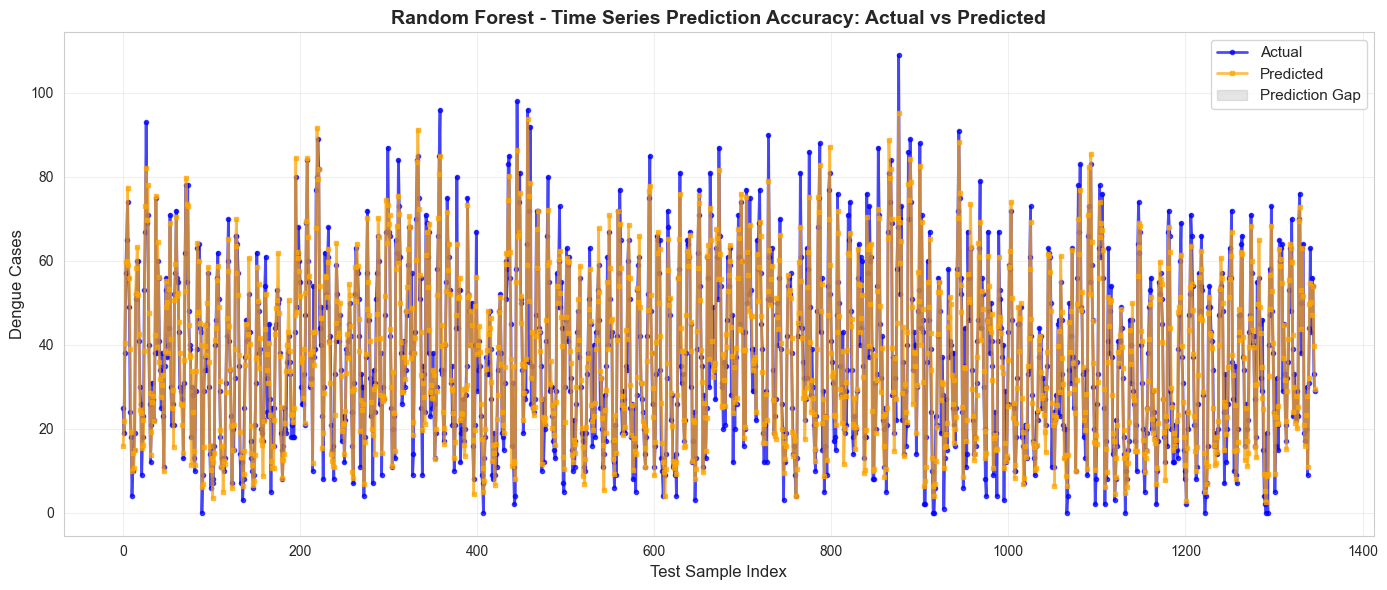

In [20]:
# Prediction Accuracy by Range
test_indices = np.arange(len(y_test))

plt.figure(figsize=(14, 6))
plt.plot(test_indices, y_test.values, label='Actual', alpha=0.7, linewidth=2, color='blue', marker='o', markersize=3)
plt.plot(test_indices, y_pred, label='Predicted', alpha=0.7, linewidth=2, color='orange', marker='s', markersize=3)
plt.fill_between(test_indices, y_test.values, y_pred, alpha=0.2, color='gray', label='Prediction Gap')
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Dengue Cases', fontsize=12)
plt.title('Random Forest - Time Series Prediction Accuracy: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

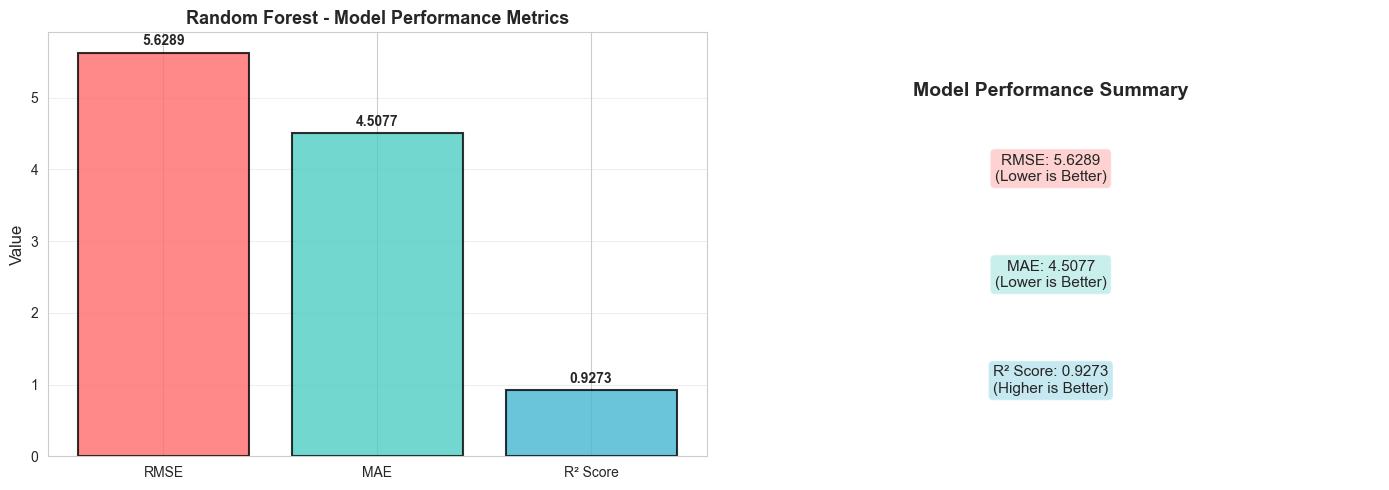

In [16]:
# Metrics Summary Visualization
metrics_data = {
    'Metric': ['RMSE', 'MAE', 'R² Score'],
    'Value': [rmse, mae, r2],
    'Normalized': [rmse/100, mae/100, r2]
}
metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(metrics_df['Metric'], metrics_df['Value'], color=colors_list, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Random Forest - Model Performance Metrics', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(metrics_df['Value']):
    axes[0].text(i, v + 0.1, f'{v:.4f}', ha='center', fontweight='bold')

metric_info = [
    f'RMSE: {rmse:.4f}\n(Lower is Better)',
    f'MAE: {mae:.4f}\n(Lower is Better)',
    f'R² Score: {r2:.4f}\n(Higher is Better)'
]
axes[1].axis('off')
axes[1].text(0.5, 0.85, 'Model Performance Summary', ha='center', fontsize=14, fontweight='bold')
for i, info in enumerate(metric_info):
    axes[1].text(0.5, 0.65 - i*0.25, info, ha='center', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor=colors_list[i], alpha=0.3))

plt.tight_layout()
plt.show()

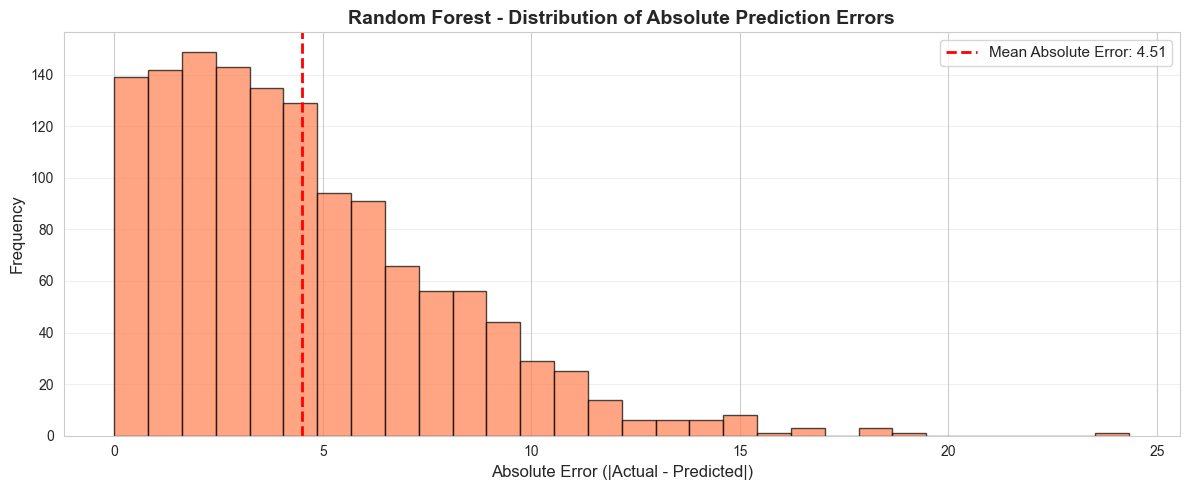

Max Error: 24.3393
Min Error: 0.0006
Median Error: 3.9005


In [14]:
# Prediction Error Distribution
errors = np.abs(residuals)
plt.figure(figsize=(12, 5))
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Absolute Error (|Actual - Predicted|)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Random Forest - Distribution of Absolute Prediction Errors', fontsize=14, fontweight='bold')
plt.axvline(x=mae, color='r', linestyle='--', linewidth=2, label=f'Mean Absolute Error: {mae:.2f}')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Max Error: {errors.max():.4f}')
print(f'Min Error: {errors.min():.4f}')
print(f'Median Error: {np.median(errors):.4f}')

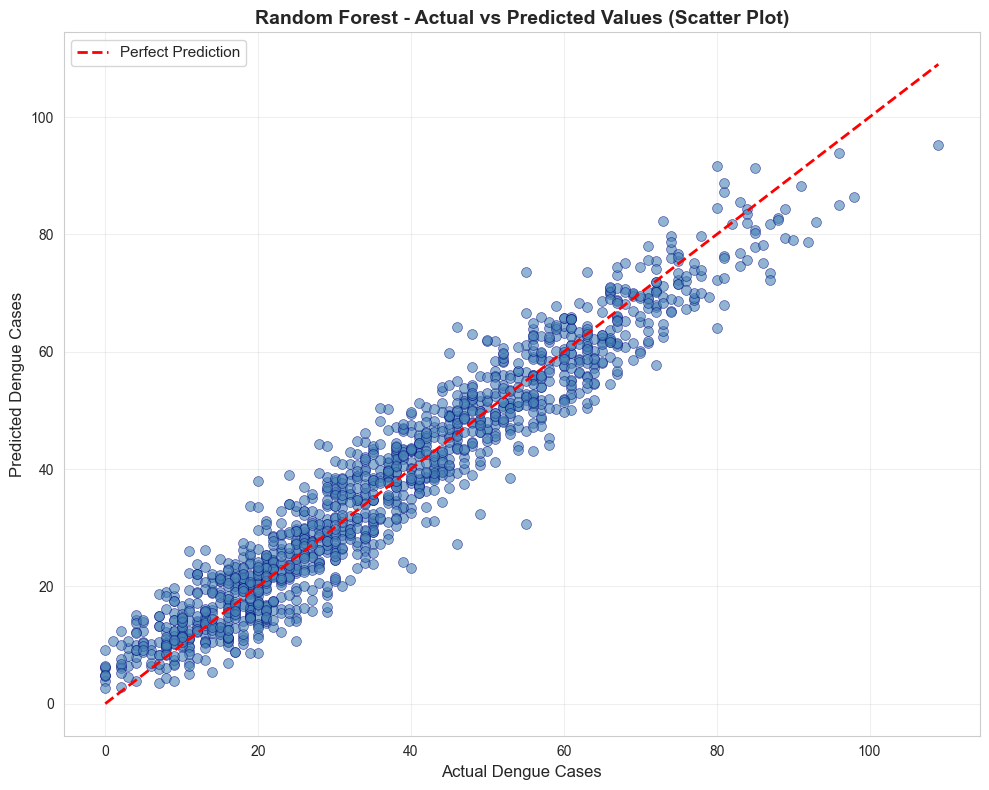

In [15]:
# Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, s=50, color='steelblue', edgecolors='navy', linewidth=0.5)
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Dengue Cases', fontsize=12)
plt.ylabel('Predicted Dengue Cases', fontsize=12)
plt.title('Random Forest - Actual vs Predicted Values (Scatter Plot)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

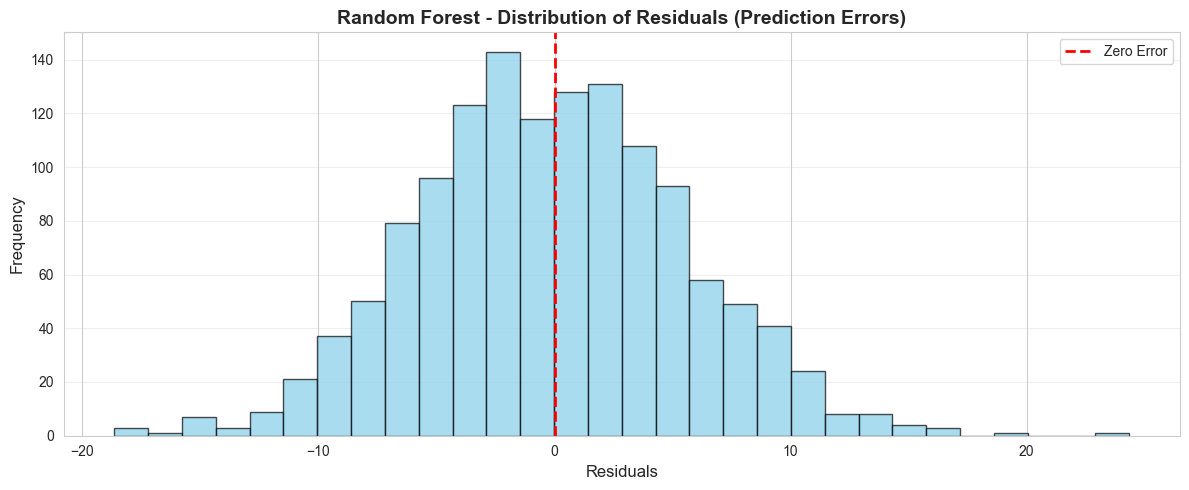

In [13]:
# Distribution of Residuals
plt.figure(figsize=(12, 5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Random Forest - Distribution of Residuals (Prediction Errors)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

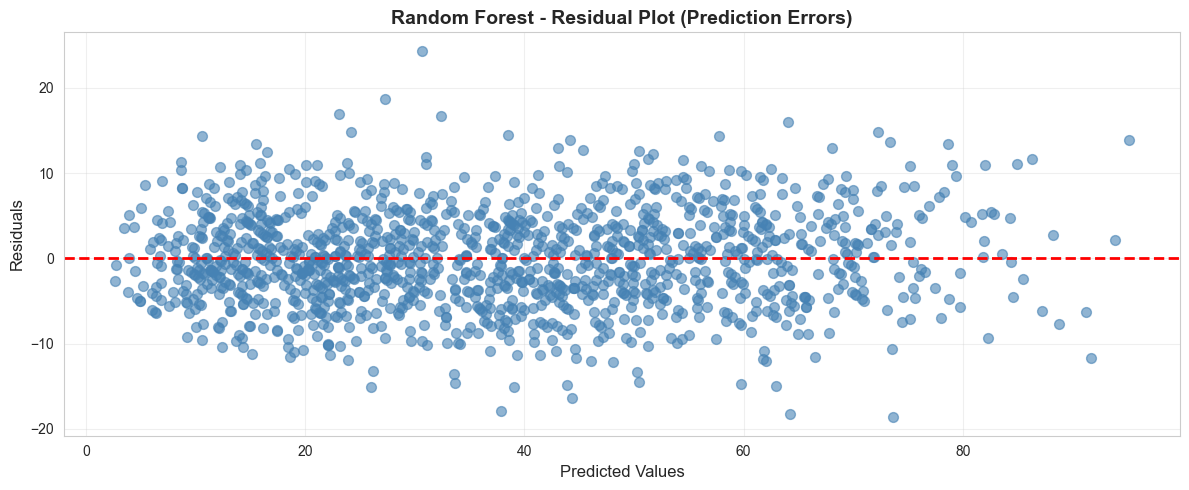

Mean of Residuals: -0.1057
Std Dev of Residuals: 5.6279


In [12]:
# Residuals Plot
residuals = y_test.values - y_pred
plt.figure(figsize=(12, 5))
plt.scatter(y_pred, residuals, alpha=0.6, s=50, color='steelblue')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Random Forest - Residual Plot (Prediction Errors)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean of Residuals: {np.mean(residuals):.4f}')
print(f'Std Dev of Residuals: {np.std(residuals):.4f}')

In [17]:
# Save the Model
import os

model_save_path = 'model_random_forest.joblib'
joblib.dump(rf_model, model_save_path)
print(f'Random Forest model saved to {model_save_path}')

# Save results to CSV
results_df = pd.DataFrame([rf_results])
results_df.to_csv('random_forest_results.csv', index=False)
print('Results saved to random_forest_results.csv')

Random Forest model saved to model_random_forest.joblib
Results saved to random_forest_results.csv


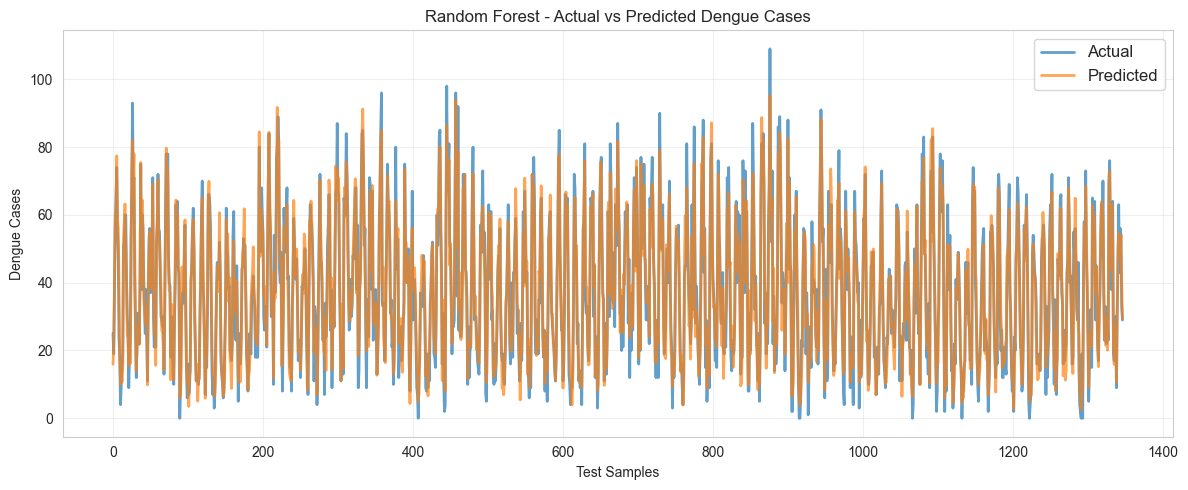

In [19]:
# Actual vs Predicted Plot
plt.figure(figsize=(12, 5))
plt.plot(list(y_test.values), label='Actual', alpha=0.7, linewidth=2)
plt.plot(list(y_pred), label='Predicted', alpha=0.7, linewidth=2)
plt.xlabel('Test Samples')
plt.ylabel('Dengue Cases')
plt.legend(fontsize=12)
plt.title('Random Forest - Actual vs Predicted Dengue Cases')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plotting Feature Importance...


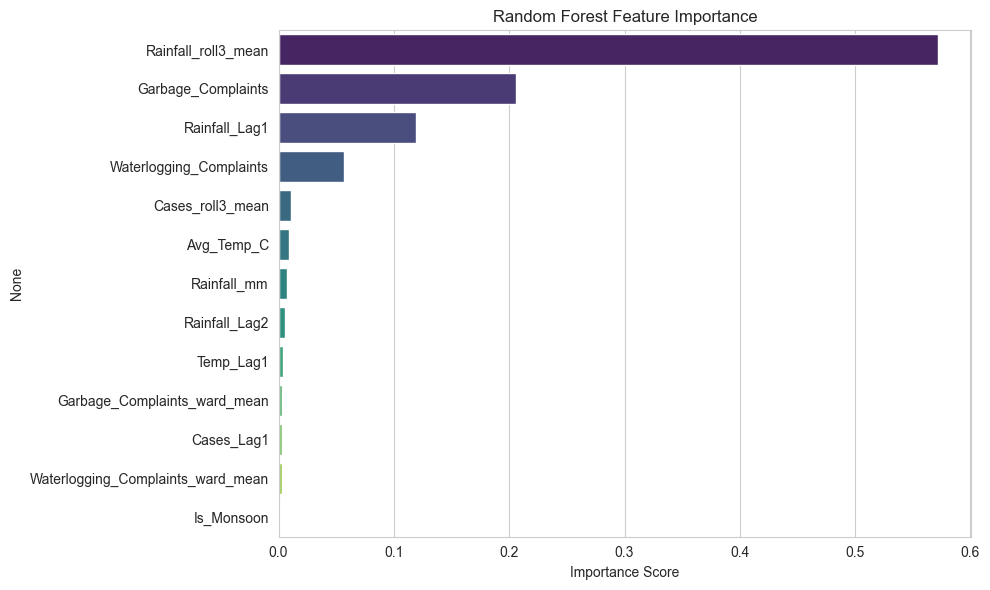

In [18]:
# Feature Importance Plot
print('Plotting Feature Importance...')
feat_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [21]:
# Train Random Forest Model
print('Training Random Forest Model...')
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\n=== Random Forest Model Results ===')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

# Save results to dictionary
rf_results = {
    'model': 'Random Forest',
    'rmse': rmse,
    'mae': mae,
    'r2': r2
}
print(f'\nResults: {rf_results}')

Training Random Forest Model...

=== Random Forest Model Results ===
RMSE: 5.6289
MAE: 4.5077
R² Score: 0.9273

Results: {'model': 'Random Forest', 'rmse': np.float64(5.628875617740406), 'mae': 4.5077032804500945, 'r2': 0.9272773027733512}


In [22]:
# Prepare Data for Random Forest
features = [
    'Rainfall_mm','Avg_Temp_C','Garbage_Complaints','Waterlogging_Complaints',
    'Rainfall_Lag1','Rainfall_Lag2','Temp_Lag1','Cases_Lag1',
    'Rainfall_roll3_mean','Cases_roll3_mean','Is_Monsoon','Garbage_Complaints_ward_mean','Waterlogging_Complaints_ward_mean'
]
target = 'Dengue_Cases'

X = df_fe[features].copy()
y = df_fe[target].copy()

# Chronological train/test split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

print(f'Train rows: {len(X_train)}, Test rows: {len(X_test)}')

Train rows: 5385, Test rows: 1347


In [23]:
# Feature Engineering
df_fe = df.sort_values(['Ward_ID','Date']).reset_index(drop=True).copy()

# Lag features
df_fe['Rainfall_Lag1'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].shift(1)
df_fe['Rainfall_Lag2'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].shift(2)
df_fe['Temp_Lag1'] = df_fe.groupby('Ward_ID')['Avg_Temp_C'].shift(1)
df_fe['Cases_Lag1'] = df_fe.groupby('Ward_ID')['Dengue_Cases'].shift(1)

# Rolling means (3-month)
df_fe['Rainfall_roll3_mean'] = df_fe.groupby('Ward_ID')['Rainfall_mm'].rolling(window=3, min_periods=1).mean().reset_index(0,drop=True)
df_fe['Cases_roll3_mean'] = df_fe.groupby('Ward_ID')['Dengue_Cases'].rolling(window=3, min_periods=1).mean().reset_index(0,drop=True)

# Temporal features
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['Year'] = df_fe['Date'].dt.year
df_fe['Is_Monsoon'] = df_fe['Month'].isin([6,7,8,9]).astype(int)

# Ward-level aggregates
ward_agg = df_fe.groupby('Ward_ID')[['Garbage_Complaints','Waterlogging_Complaints']].mean().rename(columns=lambda x: x+'_ward_mean')
df_fe = df_fe.merge(ward_agg, left_on='Ward_ID', right_index=True)

# Drop NA from lags
df_fe = df_fe.dropna().reset_index(drop=True)
print(f'After Feature Engineering rows: {len(df_fe)}')

After Feature Engineering rows: 6732


In [ ]:
# Load Dataset
df = pd.read_csv('bengaluru_wards_dataset.csv')
print(f'Dataset rows: {len(df)}, columns: {list(df.columns)}')

if 'Date' not in df.columns:
    df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
else:
    df['Date'] = pd.to_datetime(df['Date'])

print('\nDataset Info:')
df.head()

Dataset rows: 7128, columns: ['Ward_ID', 'Year', 'Month', 'Rainfall_mm', 'Avg_Temp_C', 'Garbage_Complaints', 'Waterlogging_Complaints', 'Dengue_Cases', 'Risk_Level', 'Date']

Dataset Info:


,Ward_ID,Year,Month,Rainfall_mm,Avg_Temp_C,Garbage_Complaints,Waterlogging_Complaints,Dengue_Cases,Risk_Level,Date
0,1,2021,1,5.7,20.4,35,5,22,Medium,2021-01-01
1,1,2021,2,14.5,18.3,25,4,11,Low,2021-02-01
2,1,2021,3,5.1,32.6,20,3,15,Low,2021-03-01
3,1,2021,4,1.2,38.3,21,7,16,Low,2021-04-01
4,1,2021,5,98.0,32.5,20,16,18,Low,2021-05-01


In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Random Forest Model - Dengue Prediction

This notebook trains a Random Forest regressor model for dengue case prediction in Bengaluru wards.